# Root finding
## Open methods
The fixpt function does a simple fixed‑point iteration to solve (x = g(x)):

Starts from x0, applies g each loop: x1 = g(x0).
Computes the relative change ea = abs((x1 - x0) / x1); stops early when this drops below Ea (default 1e-7) or after maxit iterations (default 30).
Returns (x1, ea, i+1) → the latest estimate, the last relative error, and how many iterations were performed.
In cell 2, g_store wraps the same g used for the friction factor so it can record each f estimate in fvals, then calls fixpt(g_store, f0) to run the iterations, and plots the stored sequence to show convergence.

In [1]:
def fixpt(g,x0,Ea=1.e-7,maxit=30):
    """
    This function solves x=g(x) using fixed-point iteration.
    The method is repeated until either the relative error
    falls below Ea (default 1.e-7) or reaches maxit (default 30).
    Input:
        g = name of the function for g(x)
        x0 = initial guess for x
        Ea = relative error threshold
        maxit = maximum number of iterations
    Output:
        x1 = solution estimate
        ea = relative error
        i+1 = number of iterations
    """    
    for i in range(maxit):
        x1 = g(x0)
        ea = abs((x1-x0)/x1)
        if ea < Ea:  break
        x0 = x1
    return x1,ea,i+1



In [2]:
# Example solving the root for f(x) = e^(-x) - x = 0
import math
def g(x):
    return math.exp(-x)
x0 = 0.5
solution, error, iterations = fixpt(g, x0)
print(f"Solution: {solution}, Relative Error: {error}, Iterations: {iterations}")


Solution: 0.5671433057511783, Relative Error: 7.474599581359157e-08, Iterations: 27


In [3]:
def f(x):
    return math.exp(-x) - x
print(f"f(Solution) = {f(solution)}")

f(Solution) = -2.404216337126286e-08


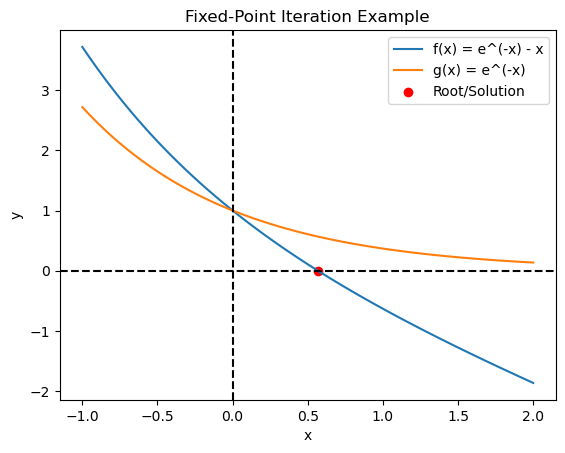

In [4]:
# plot f(x) and g(x)
import numpy as np
import matplotlib.pyplot as plt 
x = np.linspace(-1,2,100)
fx = np.exp(-x) - x
gx = np.exp(-x)
plt.plot(x,fx,label='f(x) = e^(-x) - x')
plt.plot(x,gx,label='g(x) = e^(-x)')
plt.axhline(0,color='black',ls='--')
plt.axvline(0,color='black',ls='--')
plt.scatter(solution,0,color='red',label='Root/Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Fixed-Point Iteration Example')
plt.legend()

### Why fixed-point error appears linear on a semilog plot

In fixed-point iteration,

$$
x_{k+1} = g(x_k),
$$

the error relative to the true solution $x^*$ is

$$
e_k = x_k - x^*.
$$

Near the solution, a Taylor expansion gives

$$
e_{k+1} \approx g'(x^*)\, e_k.
$$

Thus, the error at each iteration is **proportional to the previous error**:

$$
|e_{k+1}| \approx \lambda |e_k|, \qquad \lambda = |g'(x^*)| < 1.
$$

Repeating this relation,

$$
|e_k| \approx \lambda^k |e_0|.
$$

Taking logarithms,

$$
\log |e_k| = \log |e_0| + k \log \lambda,
$$

which is the equation of a **straight line in the iteration number $k$**.  
Therefore, when the error is plotted on a **logarithmic scale**, fixed-point iteration shows a **constant slope**, characteristic of **linear convergence**.


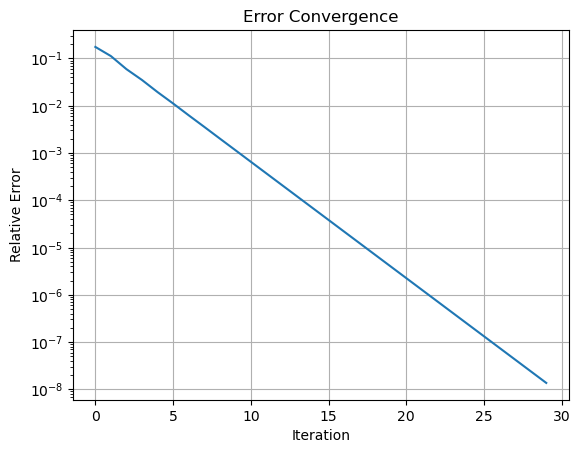

In [5]:
# make plots illustrating convergence
import numpy as np
import matplotlib.pyplot as plt 
# make a plot of the error convergence
errors = []
x0 = 0.5
for i in range(30):
    x1 = g(x0)
    ea = abs((x1-x0)/x1)
    errors.append(ea)
    x0 = x1 
plt.plot(errors)
plt.yscale('log')
plt.title('Error Convergence')
plt.xlabel('Iteration')
plt.ylabel('Relative Error')
plt.grid()
plt.show()

Example below: g(f) is the Colebrook–White relationship rearranged as a fixed‑point update for the Fanning friction factor in turbulent pipe flow. Given a current guess f, it computes a new friction‑factor estimate that balances viscous effects (via Reynolds number Re) and wall roughness (eps, pipe diameter D). Iterating g solves the implicit Colebrook equation that links friction factor to flow regime and roughness, i.e., the dimensionless resistance to flow (pressure drop) in the pipe.

### Fixed-Point Iteration for the Fanning Friction Factor

In turbulent pipe flow, the **Fanning friction factor** \( f \) is defined implicitly by an empirical logarithmic relation:

$$
\frac{1}{\sqrt{f}} = -4 \log_{10}\!\left(
\frac{\varepsilon}{3.7D} + \frac{1.26}{\mathrm{Re}\sqrt{f}}
\right),
$$

where \( \mathrm{Re} \) is the Reynolds number, \( D \) the pipe diameter, and \( \varepsilon \) the wall roughness.  
Because \( f \) appears inside both a logarithm and a square root, the equation cannot be solved analytically.

To apply a **fixed-point (open) method**, the equation is rearranged into the form

$$
f = g(f) =
\frac{1}{\left[-4 \log_{10}\!\left(
\frac{\varepsilon}{3.7D} + \frac{1.26}{\mathrm{Re}\sqrt{f}}
\right)\right]^2}.
$$

Starting from an initial guess \( f_0 \), the iteration

$$
f_{k+1} = g(f_k)
$$

is repeated until the relative change between successive estimates is sufficiently small.  
Convergence depends on the chosen rearrangement and the initial guess, making this a useful example of the strengths and limitations of fixed-point methods.


In [6]:
import numpy as np
rho = 1.23  # kg/m3
mu = 1.79e-5  # Pa*s
D = 0.005  # m
V = 40  # m/s
eps = 1.5e-6  # m
Re = rho*V*D/mu  # Reynolds number

def g(f):
    fr = -4*np.log10(eps/3.7/D+1.26/Re/np.sqrt(f))
    return 1/fr**2

f0 = 0.001
fsoln,ea,n = fixpt(g,f0)
print('Fanning friction factor = ',fsoln)
print('Relative error = ',ea)
print('Number of iterations = ',n)



Fanning friction factor =  0.007248917198656729
Relative error =  4.330091759458145e-08
Number of iterations =  10


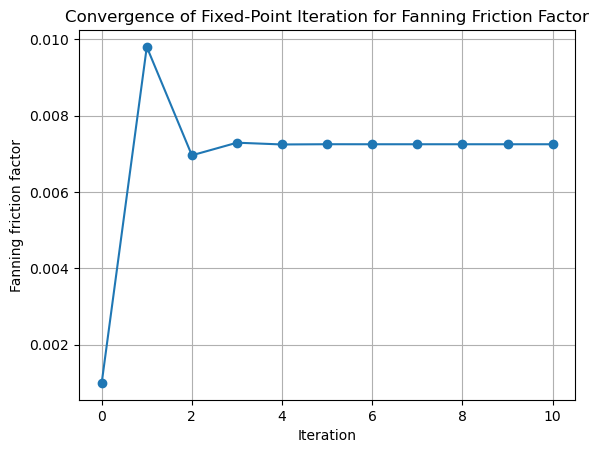

In [7]:
# make plots illustrating convergence
import matplotlib.pyplot as plt 
fvals = []
def g_store(f):
    f_new = g(f)
    fvals.append(f_new)
    return f_new    
fvals.append(f0)
fixpt(g_store,f0)
plt.plot(fvals,'o-')
plt.xlabel('Iteration')
plt.ylabel('Fanning friction factor')
plt.title('Convergence of Fixed-Point Iteration for Fanning Friction Factor')
plt.grid()
plt.show()


# Shear stress-strain example again

In [8]:
import numpy as np

# Given parameters (from the figure)
G0 = 2.0        # kPa
A  = 1.0e-2     # dimensionless
tau_target = 145.0  # kPa

def tau(gamma, G0=G0, A=A):
    """Shear stress tau(gamma) in kPa."""
    return G0/A - G0/(A + gamma)

def f(gamma):
    """Root function: tau(gamma) - tau_target."""
    return tau(gamma) - tau_target


def bisection(f, a, b, tol=1e-10, max_iter=200):
    """
    Bisection (bracketing) method for f(x)=0 on [a,b].
    Requires f(a)*f(b) < 0.
    Returns (root, iterations, approx_errors, iterates).
    """
    fa, fb = f(a), f(b)
    if fa == 0:
        return a, 0, np.array([]), np.array([])
    if fb == 0:
        return b, 0, np.array([]), np.array([])
    if fa * fb > 0:
        raise ValueError("Interval does not bracket a root: f(a) and f(b) must have opposite signs.")

    approx_errors = []
    iterates = []
    c_old = None

    for k in range(1, max_iter + 1):
        c = 0.5 * (a + b)
        fc = f(c)

        if c_old is None:
            ea = np.nan
        else:
            ea = abs((c - c_old) / c)
        approx_errors.append(ea)
        iterates.append(c)

        # Stopping criteria: small function value OR small interval
        if abs(fc) < tol or 0.5 * (b - a) < tol:
            return c, k, np.array(approx_errors), np.array(iterates)

        # Keep the sub-interval that still brackets the root
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc

        c_old = c

    # If we get here, we hit max_iter
    return 0.5 * (a + b), max_iter, np.array(approx_errors), np.array(iterates)


# --- Step 1: Find a bracket [a,b] ---
# We know tau(0)=0 so f(0) = -145 < 0.
# Also tau(gamma) approaches G0/A = 200, so f(gamma) becomes positive for some gamma.
a = 0.0
b = 0.1  # from the plot range; should be enough to exceed 150 kPa

print("f(a) =", f(a))
print("f(b) =", f(b))

# If b is not enough (rare here), expand b until it brackets
while f(a) * f(b) > 0:
    b *= 2
    if b > 1e6:
        raise RuntimeError("Failed to find a bracket for the root.")
    print("Expanding bracket, new b =", b, "f(b) =", f(b))

# here for comparison with the lecture, we fix the bracket
a=2e-2
b=4e-2
# --- Step 2: Solve with bisection ---
gamma_star, iters, approx_errors, iterates = bisection(f, a, b, tol=1e-12)

print(f"\nStrain where tau = {tau_target:.1f} kPa:")
print(f"gamma* = {gamma_star:.6e}  (found in {iters} iterations)")

# Quick check
print(f"tau(gamma*) = {tau(gamma_star):.6f} kPa")
print(f"error = tau(gamma*) - target = {tau(gamma_star) - tau_target:.3e} kPa")



f(a) = -145.0
f(b) = 36.81818181818181

Strain where tau = 145.0 kPa:
gamma* = 2.636364e-02  (found in 35 iterations)
tau(gamma*) = 145.000000 kPa
error = tau(gamma*) - target = 7.203e-10 kPa


### Fixed-Point Formulation

We start from the nonlinear stress–strain relation written at the target stress level:

$$
\tau_{\text{target}} = \frac{G_0}{A} - \frac{G_0}{A + \gamma}.
$$

Rearranging step by step,

$$
\frac{G_0}{A + \gamma} = \frac{G_0}{A} - \tau_{\text{target}},
$$

$$
A + \gamma = \frac{G_0}{\frac{G_0}{A} - \tau_{\text{target}}},
$$

and finally,

$$
\gamma = \frac{G_0}{\frac{G_0}{A} - \tau_{\text{target}}} - A.
$$

This expression defines a fixed-point map \( \gamma = g(\gamma) \) that is **independent of \( \gamma \)**.  
As a result, the fixed-point iteration converges in a single step for any reasonable initial guess.


In [9]:
import numpy as np

# Given parameters (from the figure)
G0 = 2.0        # kPa
A  = 1.0e-2     # dimensionless
tau_target = 145.0  # kPa

def tau(gamma, G0=G0, A=A):
    """Shear stress tau(gamma) in kPa."""
    return G0/A - G0/(A + gamma)

def f(gamma):
    """Root function: tau(gamma) - tau_target."""
    return tau(gamma) - tau_target


# -----------------------------
# Fixed-point formulation
# -----------------------------
# Start from: tau_target = G0/A - G0/(A+gamma)
# => G0/(A+gamma) = G0/A - tau_target
# => A + gamma = G0 / (G0/A - tau_target)
# => gamma = G0/(G0/A - tau_target) - A
#
# This mapping is a constant (independent of gamma), so fixed-point converges in 1 iteration.

def g_fp(gamma, G0=G0, A=A, tau_target=tau_target):
    """Fixed-point map gamma_{k+1} = g(gamma_k) for tau(gamma)=tau_target."""
    denom = (G0/A - tau_target)
    if denom <= 0:
        raise ValueError("No physical solution: need tau_target < G0/A for this model.")
    return G0/denom - A


def fixpt(g, x0, tol=1e-12, max_iter=50):
    """
    Fixed-point iteration: x_{k+1} = g(x_k)
    Returns (x, ea, n, errors, iterates).
    ea is approximate relative error at termination.
    """
    x_old = x0
    errors = []
    iterates = []

    for n in range(1, max_iter + 1):
        x_new = g(x_old)

        # approximate relative error
        if x_new != 0:
            ea = abs((x_new - x_old) / x_new)
        else:
            ea = abs(x_new - x_old)

        errors.append(ea)
        iterates.append(x_new)

        if ea < tol:
            return x_new, ea, n, np.array(errors), np.array(iterates)

        x_old = x_new

    # max_iter reached
    return x_new, ea, max_iter, np.array(errors), np.array(iterates)


# --- Run fixed-point ---
gamma0 = 0.001  # initial guess (any reasonable value works here)
gamma_star, ea, n, errors, iterates = fixpt(lambda x: g_fp(x), gamma0, tol=1e-12)

print(f"Fixed-point solution for tau = {tau_target:.1f} kPa:")
print(f"gamma* = {gamma_star:.6e}")
print(f"Relative error ea = {ea:.3e}")
print(f"Number of iterations = {n}")

# Quick check
print(f"tau(gamma*) = {tau(gamma_star):.6f} kPa")
print(f"error = tau(gamma*) - target = {tau(gamma_star) - tau_target:.3e} kPa")

# Optional: show iteration history
print("\nIterates:")
for k, (xk, ek) in enumerate(zip(iterates, errors), start=1):
    print(f"k={k:2d}: gamma={xk:.6e}, ea={ek:.3e}")


Fixed-point solution for tau = 145.0 kPa:
gamma* = 2.636364e-02
Relative error ea = 0.000e+00
Number of iterations = 2
tau(gamma*) = 145.000000 kPa
error = tau(gamma*) - target = 0.000e+00 kPa

Iterates:
k= 1: gamma=2.636364e-02, ea=9.621e-01
k= 2: gamma=2.636364e-02, ea=0.000e+00


### Why a `lambda` Function Is Used in Fixed-Point Iteration

The fixed-point algorithm is written in the form

$$
x_{k+1} = g(x_k),
$$

which means that the function passed to the solver must depend on **one variable only**: the unknown being iterated.

In this problem, the fixed-point map is defined as

$$
\gamma = g(\gamma; G_0, A, \tau_{\text{target}}),
$$

where \( G_0 \), \( A \), and \( \tau_{\text{target}} \) are physical parameters.  
Although these parameters are fixed, they are still part of the function definition.

Using a `lambda` function,

```python
lambda x: g_fp(x)


In [10]:
import numpy as np

# Given parameters
G0 = 2.0        # kPa
A  = 1.0e-2     # dimensionless
tau_target = 145.0  # kPa

def tau(gamma, G0=G0, A=A):
    """Shear stress tau(gamma) in kPa."""
    return G0/A - G0/(A + gamma)

def f(gamma):
    """Root function: tau(gamma) - tau_target."""
    return tau(gamma) - tau_target


# -----------------------------------------
# "Interesting" fixed-point (relaxed) form:
# gamma_{k+1} = gamma_k - omega * (tau(gamma_k) - tau_target)
# This is fixed-point with g(gamma) = gamma - omega*f(gamma)
# -----------------------------------------

def g_relaxed(gamma, omega):
    return gamma - omega * f(gamma)


def fixpt(g, x0, tol=1e-12, max_iter=200):
    """
    Fixed-point iteration: x_{k+1} = g(x_k)
    Returns (x, ea, n, errors, iterates).
    """
    x_old = x0
    errors = []
    iterates = []

    for n in range(1, max_iter + 1):
        x_new = g(x_old)

        # approximate relative error
        if x_new != 0:
            ea = abs((x_new - x_old) / x_new)
        else:
            ea = abs(x_new - x_old)

        errors.append(ea)
        iterates.append(x_new)

        if ea < tol:
            return x_new, ea, n, np.array(errors), np.array(iterates)

        x_old = x_new

    return x_new, ea, max_iter, np.array(errors), np.array(iterates)


# ---- Choose an initial guess near your bisection bracket ----
gamma0 = 0.02

# ---- Choose a relaxation parameter omega ----
# Needs to be small enough to converge.
# For a safe start: omega ~ 1e-3 to 1e-4 works well here (units: 1/kPa).
omega = 1e-3

gamma_star, ea, n, errors, iterates = fixpt(lambda x: g_relaxed(x, omega), gamma0, tol=1e-12)

print(f"Relaxed fixed-point solution for tau = {tau_target:.1f} kPa:")
print(f"gamma* = {gamma_star:.6e}")
print(f"Relative error ea = {ea:.3e}")
print(f"Number of iterations = {n}")

# Quick check
print(f"tau(gamma*) = {tau(gamma_star):.6f} kPa")
print(f"error = tau(gamma*) - target = {tau(gamma_star) - tau_target:.3e} kPa")


# ---- OPTIONAL: try a few omega values to show convergence/divergence ----
omegas = [5e-4, 1e-3, 2e-3, 5e-3]  # last one might overshoot depending on start
print("\nSweep over omega to illustrate behavior:")
for om in omegas:
    try:
        gs, ea_s, n_s, _, _ = fixpt(lambda x: g_relaxed(x, om), gamma0, tol=1e-10, max_iter=200)
        print(f"omega={om:.1e} -> gamma*={gs:.6e}, iters={n_s:3d}, ea={ea_s:.1e}, f(gamma*)={f(gs):+.2e}")
    except Exception as e:
        print(f"omega={om:.1e} -> failed: {e}")


# ---- OPTIONAL: print first few iterations (nice for teaching) ----
print("\nFirst 10 iterates (omega = {:.1e}):".format(omega))
for k in range(min(10, len(iterates))):
    gk = iterates[k]
    print(f"k={k+1:2d}: gamma={gk:.6e}, tau={tau(gk):.3f} kPa, f={f(gk):+.3e}, ea={errors[k]:.3e}")


Relaxed fixed-point solution for tau = 145.0 kPa:
gamma* = 2.636364e-02
Relative error ea = 9.778e-13
Number of iterations = 41
tau(gamma*) = 145.000000 kPa
error = tau(gamma*) - target = 1.319e-11 kPa

Sweep over omega to illustrate behavior:
omega=5.0e-04 -> gamma*=2.636364e-02, iters= 16, ea=3.7e-11, f(gamma*)=-4.81e-10
omega=1.0e-03 -> gamma*=2.636364e-02, iters= 35, ea=5.4e-11, f(gamma*)=+7.29e-10
omega=2.0e-03 -> gamma*=1.382323e-01, iters=200, ea=9.5e-01, f(gamma*)=+4.15e+01
omega=5.0e-03 -> gamma*=-5.484979e+01, iters=200, ea=5.0e-03, f(gamma*)=+5.50e+01

First 10 iterates (omega = 1.0e-03):
k= 1: gamma=3.166667e-02, tau=152.000 kPa, f=+7.000e+00, ea=3.684e-01
k= 2: gamma=2.466667e-02, tau=142.308 kPa, f=-2.692e+00, ea=2.838e-01
k= 3: gamma=2.735897e-02, tau=146.465 kPa, f=+1.465e+00, ea=9.841e-02
k= 4: gamma=2.589363e-02, tau=144.280 kPa, f=-7.202e-01, ea=5.659e-02
k= 5: gamma=2.661382e-02, tau=145.376 kPa, f=+3.758e-01, ea=2.706e-02
k= 6: gamma=2.623800e-02, tau=144.809 kPa, 

## Newton-Raphson
The function newtraph below is a small Newton–Raphson solver for scalar equations f(x)=0:

Inputs: 
f (function), fp (its derivative), initial guess x0, relative error tolerance Ea (default 1e-7), and maxit (default 30).
Loop: computes the Newton step x1 = x0 - f(x0) / fp(x0), then the relative change ea = abs((x1 - x0) / x1). Stops early when ea < Ea or after maxit steps, otherwise sets x0 = x1 and repeats.
Returns (x1, f(x1), ea, i+1): the root estimate, the residual at that point, the last relative error, and iteration count.


In [19]:
def newtraph(f,fp,x0,Ea=1.e-7,maxit=30):
    """
    This function solves f(x)=0 using the Newton-Raphson method.
    The method is repeated until either the relative error
    falls below Ea (default 1.e-7) or reaches maxit (default 30).
    Input:
        f = name of the function for f(x)
        fp = name of the function for f'(x)
        x0 = initial guess for x
        Ea = relative error threshold
        maxit = maximum number of iterations
    Output:
        x1 = solution estimate
        f(x1) = equation error at solution estimate
        ea = relative error
        i+1 = number of iterations
    """    
    for i in range(maxit):
        x1 = x0 - f(x0)/fp(x0)
        ea = abs((x1-x0)/x1)
        if ea < Ea:  break
        x0 = x1
    return x1,f(x1),ea,i+1



**Example**

- Define the function $$ f(x) = x^2 - 9, $$  
  with derivative $$ f'(x) = 2x. $$

- Choose an initial guess $x_0 = 5$.

- Apply the Newton–Raphson method by calling  
  `newtraph(f, fp, x0, Ea=1e-5)`.

- The Newton iterations converge to the positive root of  
  $x^2 - 9 = 0$, which is  
  $$x \approx 3.$$

- The output includes:
  - the estimated root,
  - the value of $f(x)$ at the estimate (close to zero),
  - the final relative error (below $10^{-5}$),
  - and the number of iterations required for convergence.


In [22]:
def f(x):
    return x**2-9

def fp(x):
    return 2*x

x0 = 5
(xsoln,fxsoln,ea,n) = newtraph(f,fp,x0,Ea=1.e-5)
print('Solution = {0:8.5g}'.format(xsoln))
print('Function value at solution = {0:8.5e}'.format(fxsoln))
print('Relative error = {0:8.3e}'.format(ea))
print('Number of iterations = {0:5d}'.format(n))


Solution =        3
Function value at solution = 0.00000e+00
Relative error = 4.657e-10
Number of iterations =     5


Text(0.5, 1.0, 'Newton-Raphson Method Example')

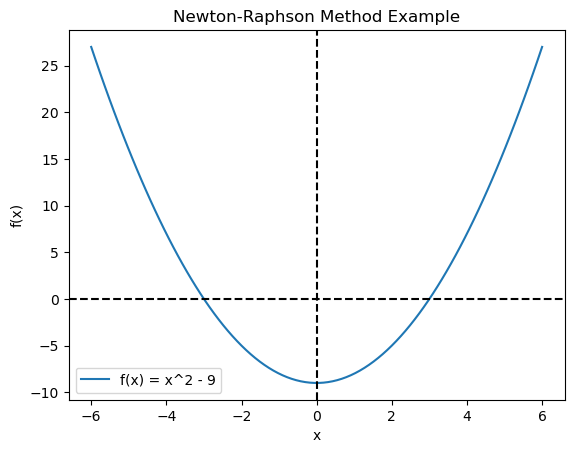

In [24]:
# plot the function f(x) and the tangent line at each iteration
import numpy as np  
import matplotlib.pyplot as plt
x = np.linspace(-6,6,100)
fx = f(x)
plt.plot(x,fx,label='f(x) = x^2 - 9')
plt.axhline(0,color='black',ls='--')
plt.axvline(0,color='black',ls='--')
plt.legend()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Newton-Raphson Method Example')

### Newton–Raphson Method for $ f(x) = e^{-x} - x $

We consider the nonlinear equation

$$
f(x) = e^{-x} - x,
$$

which arises in many applications and **has a real root**.

Newton–Raphson is an **open root-finding method** based on local linearization.  
Starting from an initial guess \( x_0 \), the iteration formula is

$$
x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}.
$$

---

### Derivative and Iteration Formula

The derivative of \( f(x) \) is

$$
f'(x) = -e^{-x} - 1.
$$

Substituting into Newton’s formula gives

$$
x_{k+1}
= x_k - \frac{e^{-x_k} - x_k}{-e^{-x_k} - 1}.
$$

---

### Convergence Behavior

- The function \( e^{-x} \) decreases monotonically, while \( x \) increases linearly.
- Their intersection produces a **single real root**.
- Near the root, Newton–Raphson converges **quadratically**, meaning the number of correct digits roughly doubles at each iteration.

For a reasonable initial guess (e.g., \( x_0 = 0.5 \)), the method converges rapidly to

$$
x \approx 0.567143,
$$

which is sometimes called the *Omega constant*.

---

### Key Takeaway

> Newton–Raphson efficiently finds the root of \( e^{-x} - x = 0 \) because the function is smooth, the derivative does not vanish near the root, and a real solution exists.

This example contrasts nicely with cases where Newton fails, highlighting the importance of both problem analysis and initial guess selection.


In [25]:
import numpy as np

# Define the function and its derivative
def f(x):
    return np.exp(-x) - x

def df(x):
    return -np.exp(-x) - 1


def newton_raphson(f, df, x0, tol=1e-10, max_iter=50):
    """
    Newton–Raphson solve for f(x)=0.

    Args:
        f (callable): Nonlinear function.
        df (callable): Derivative of f.
        x0 (float): Initial guess.
        tol (float): Convergence tolerance.
        max_iter (int): Max iterations.
    Returns:
        x (float): Estimated root.
        ea (float): Approx. relative error.
        n (int): Iteration count.
    """

    x_old = x0

    for n in range(1, max_iter + 1):
        fx = f(x_old)
        dfx = df(x_old)

        if abs(dfx) < 1e-14:
            raise ZeroDivisionError("Derivative too small; Newton step undefined.")

        x_new = x_old - fx / dfx

        # Approximate relative error
        if x_new != 0:
            ea = abs((x_new - x_old) / x_new)
        else:
            ea = abs(x_new - x_old)

        print(f"iter {n:2d}: x = {x_new:.10f}, f(x) = {f(x_new):+.3e}, ea = {ea:.3e}")

        if abs(fx) < tol or ea < tol:
            return x_new, ea, n

        x_old = x_new

    return x_new, ea, max_iter


# ---- Run Newton–Raphson ----
x0 = 0.5  # initial guess
root, ea, iters = newton_raphson(f, df, x0)

print("\nFinal result:")
print(f"Root x* = {root:.10f}")
print(f"Approximate relative error = {ea:.3e}")
print(f"Iterations = {iters}")


iter  1: x = 0.5663110032, f(x) = +1.305e-03, ea = 1.171e-01
iter  2: x = 0.5671431650, f(x) = +1.965e-07, ea = 1.467e-03
iter  3: x = 0.5671432904, f(x) = +4.441e-15, ea = 2.211e-07
iter  4: x = 0.5671432904, f(x) = -1.110e-16, ea = 5.090e-15

Final result:
Root x* = 0.5671432904
Approximate relative error = 5.090e-15
Iterations = 4


### Why Newton–Raphson error is quadratic

Newton–Raphson iteration for solving $f(x)=0$ is

$$
x_{k+1} = x_k - \frac{f(x_k)}{f'(x_k)}.
$$

Let the error relative to the true root $x^*$ be

$$
e_k = x_k - x^*.
$$

Using a Taylor expansion of $f(x_k)$ around $x^*$ and noting that $f(x^*)=0$, the leading term in the error propagation becomes

$$
e_{k+1} \approx C\, e_k^2,
$$

where $C = \dfrac{f''(x^*)}{2 f'(x^*)}$ is a constant.

This shows that the new error is **proportional to the square of the previous error**, which is called **quadratic convergence**.

Consequences:

- The number of correct digits roughly **doubles at each iteration** near the root.
- On a semilog error plot, the curve is **not a straight line** but bends downward, reflecting the faster-than-exponential decay of the error.

> Newton–Raphson converges much faster than fixed-point iteration because the error decreases proportionally to $e_k^2$ instead of $e_k$.


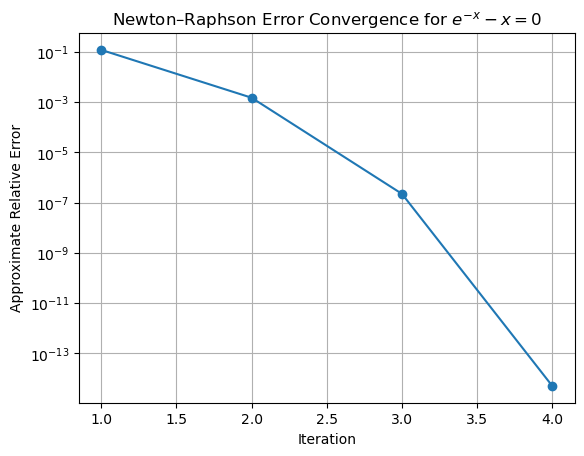

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Function and derivative
def f(x):
    return np.exp(-x) - x

def df(x):
    return -np.exp(-x) - 1


def newton_raphson_errors(f, df, x0, tol=1e-12, max_iter=20):
    """
    Newton–Raphson method that stores approximate relative errors.
    Returns arrays of iterates and errors.
    """
    x_old = x0
    xs = []
    errors = []

    for k in range(1, max_iter + 1):
        fx = f(x_old)
        dfx = df(x_old)

        if abs(dfx) < 1e-14:
            raise ZeroDivisionError("Derivative too small; Newton step undefined.")

        x_new = x_old - fx / dfx

        # Approximate relative error
        if x_new != 0:
            ea = abs((x_new - x_old) / x_new)
        else:
            ea = abs(x_new - x_old)

        xs.append(x_new)
        errors.append(ea)

        if ea < tol:
            break

        x_old = x_new

    return np.array(xs), np.array(errors)


# ---- Run method and collect errors ----
x0 = 0.5
xs, errors = newton_raphson_errors(f, df, x0)

# ---- Plot error convergence ----
plt.figure()
plt.semilogy(range(1, len(errors) + 1), errors, marker='o')
plt.xlabel("Iteration")
plt.ylabel("Approximate Relative Error")
plt.title("Newton–Raphson Error Convergence for $e^{-x} - x = 0$")
plt.grid(True)
plt.show()


## Secant method
secant is a root finder for f(x)=0 that avoids needing a derivative:

Inputs: \
f function; \
two initial guesses x0, x1; \
relative error tolerance Ea (default 1e-7); \
iteration cap maxit (default 30). 

Keeps the last two points and their function values (x0,f0 and x1,f1), \
then updates with the secant step \
(x_{2} = x_{1} - f_{1} (x_{1}-x_{0}) / (f_{1}-f_{0})). 

Computes relative change ea = abs((x2 - x1)/x2) and stops early when ea < Ea or a root is hit (f1 == 0). Raises a ZeroDivisionError if f1 == f0 (would divide by zero).

Returns (x2, f(x2), ea, i+1): the latest estimate, its residual, final relative error, and iterations performed.

In [13]:
def secant(f,x0,x1,Ea=1.e-7,maxit=30):
    """
    This function solves f(x)=0 using the secant method.
    The method is repeated until either the relative error
    falls below Ea (default 1.e-7) or reaches maxit (default 30).
    Input:
        f = name of the function for f(x)
        x0 = first initial guess for x
        x1 = second initial guess for x
        Ea = relative error threshold
        maxit = maximum number of iterations
    Output:
        x2 = solution estimate
        f(x2) = equation error at solution estimate
        ea = relative error
        i+1 = number of iterations
    """
    f0 = f(x0)
    f1 = f(x1)
    for i in range(maxit):
        denom = f1 - f0
        if denom == 0:
            raise ZeroDivisionError("Secant method breakdown: f(x1) and f(x0) are equal.")
        x2 = x1 - f1 * (x1 - x0) / denom
        f2 = f(x2)
        ea = abs((x2 - x1) / x2)
        if ea < Ea:
            break
        x0, f0, x1, f1 = x1, f1, x2, f2
    return x2, f2, ea, i+1


In [14]:
# Example usage of secant method
def f(x):
    return x**2-9

x0 = 5
x1 = 6
(xsoln,fxsoln,ea,n) = secant(f,x0,x1,Ea=1.e-5)
print('Solution = {0:8.5g}'.format(xsoln))
print('Function value at solution = {0:8.5e}'.format(fxsoln))
print('Relative error = {0:8.3e}'.format(ea))
print('Number of iterations = {0:5d}'.format(n))

# comparing with newton-raphson
def fp(x):
    return 2*x
(xsoln,fxsoln,ea,n) = newtraph(f,fp,x0,Ea=1.e-5)
print('Solution = {0:8.5g}'.format(xsoln))
print('Function value at solution = {0:8.5e}'.format(fxsoln))
print('Relative error = {0:8.3e}'.format(ea))
print('Number of iterations = {0:5d}'.format(n))


Solution =        3
Function value at solution = 3.44546e-10
Relative error = 2.977e-07
Number of iterations =     6
Solution =        3
Function value at solution = 0.00000e+00
Relative error = 4.657e-10
Number of iterations =     5


## Brent's Method 
brentsimp is an implementation of Brent’s root-finding method: it combines bisection (guaranteed bracketing) with faster open methods (secant and inverse quadratic interpolation) to find a root in [xl, xu] where f changes sign.

How it works:

Starts with endpoints a=xl, b=xu and their function values; keeps a third point c to support interpolation.
Always maintains a bracketing interval with opposite signs (fa, fb); swaps points as needed so |fb| is the smallest magnitude.
Each loop:
Checks convergence via interval half-width m=(a-b)/2 and a floating-point tolerance tol = 2*eps*max(|b|,1); exits when the interval is tiny or fb is zero.
Chooses a step:
If recent steps are reliable (abs(e) >= tol and |fc| > |fb|), tries an open-method step:
Secant when a == c.
Inverse quadratic interpolation otherwise.
Accepts the proposed step only if it’s not too aggressive (2*p < 3*m*q - |tol*q| and p < |0.5*e*q|); else falls back.
Otherwise, falls back to a bisection step (d = m).
Updates the bracket and function values and repeats.
Return value: the latest b, the best current root estimate.

Example in the same cell: brentsimp(lambda x: x**10 - 1, 0.1, 5) finds the positive root of (x^{10}-1=0), which is near x=1, starting from a sign-changing bracket [0.1, 5].

In [15]:
import numpy as np
eps = np.finfo(float).eps
def brentsimp(f,xl,xu):
    a = xl ; b = xu ; fa = f(a) ; fb = f(b)
    c = a ; fc = fa ; d = b - c ; e = d
    while True:
        if fb == 0: break
        if np.sign(fa) == np.sign(fb):  # rearrange points as req'd
            a = c ; fa = fc ; d = b - c ; e = d
        if abs(fa) < abs(fb):
            c = b ; b = a ; a = c
            fc = fb ; fb = fa ; fa = fc
        m = (a-b)/2  # termination test and possible exit
        tol = 2 * eps * max(abs(b),1)
        if abs(m) < tol or fb == 0: break
        # choose open methods or bisection
        if abs(e) >= tol and abs(fc) > abs(fb):
            s = fb/fc
            if a == c: 
                # secant method here
                p = 2*m*s
                q = 1 - s
            else:
                # inverse quadratic interpolation here
                q = fc/fa ; r = fb/fa
                p = s * (2*m*q*(q-r)-(b-c)*(r-1))
                q = (q-1)*(r-1)*(s-1)
            if p > 0: 
                q = -q
            else:
                p = -p
            if 2*p < 3*m*q - abs(tol*q) and p < abs(0.5*e*q):
                e = d ; d = p/q
            else:
                d = m ; e = m
        else:
            # bisection here
            d = m; e = m
        c = b ; fc = fb
        if abs(d) > tol:
            b = b + d
        else:
            b = b - np.sign(b-a)*tol
        fb = f(b)
    return b



In [16]:
xsoln = brentsimp(lambda x: x**10-1,0.1,5)
print('Solution = ',xsoln)

xsoln = brentsimp(lambda x: x**2-9,0.1,5)
print('Solution = ',xsoln)



Solution =  1.0
Solution =  3.0
